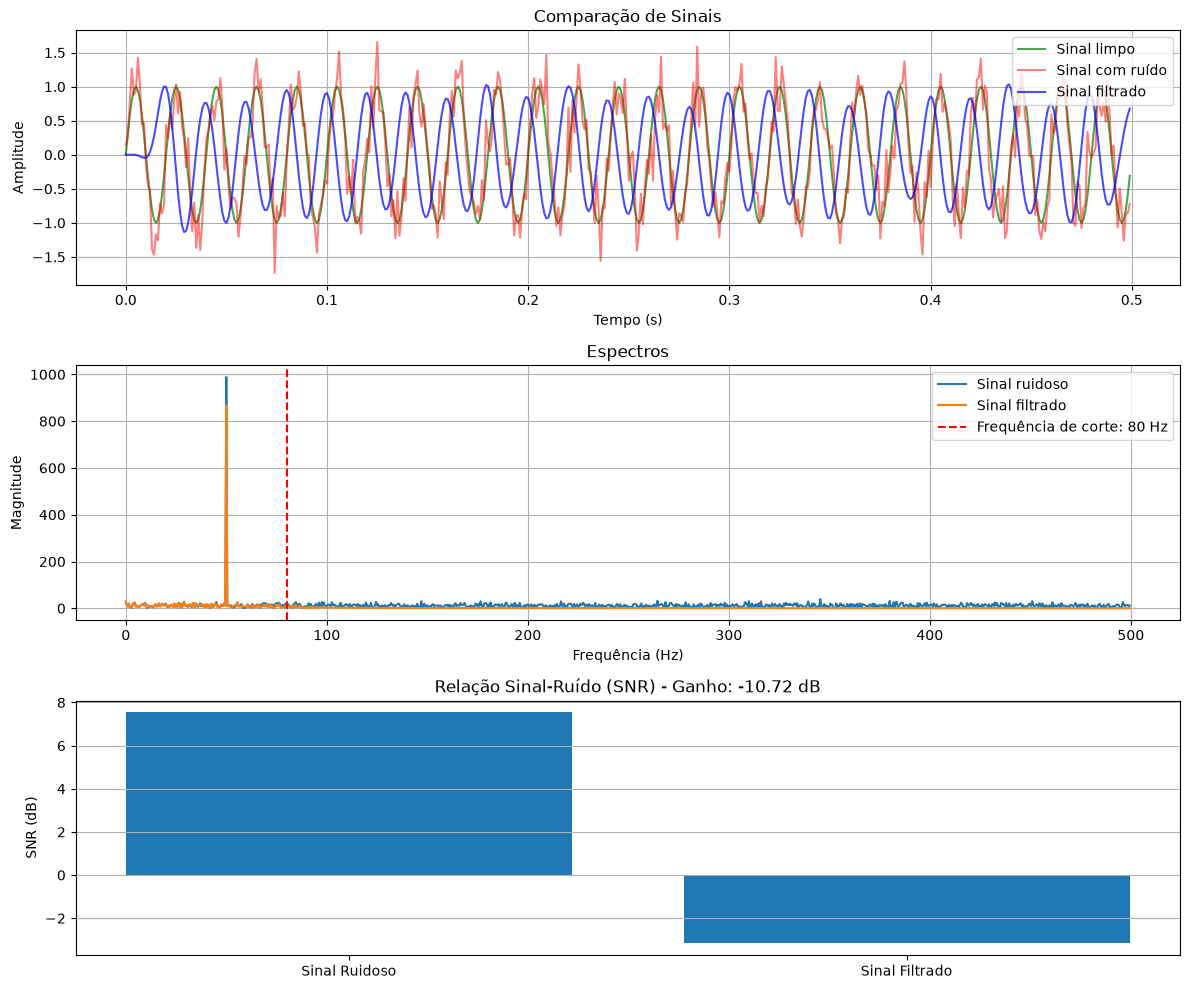

SNR do sinal ruidoso: 7.55 dB
SNR do sinal filtrado: -3.17 dB
Ganho de SNR: -10.72 dB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Parâmetros
fs = 1000
t = np.arange(0, 2, 1/fs)
f_sinal = 50  # Frequência do sinal de interesse (Hz)

# Sinal puro
sinal_limpo = np.sin(2*np.pi*f_sinal*t)

# Adição de ruído branco
np.random.seed(42)
ruido = 0.3 * np.random.randn(len(t))
sinal_ruidoso = sinal_limpo + ruido

# Projeto do filtro FIR passa-baixa
fc = 80  # Frequência de corte (Hz)
ordem = 30
b = signal.firwin(ordem, fc, fs=fs, window='hamming')

# Aplicar o filtro
sinal_filtrado = signal.lfilter(b, [1.0], sinal_ruidoso)

# Cálculo da relação sinal-ruído (SNR)
def calcular_snr(original, processado, limpo):
    ruido_original = original - limpo
    ruido_processado = processado - limpo
    snr_original = 10 * np.log10(np.var(limpo) / np.var(ruido_original))
    snr_processado = 10 * np.log10(np.var(limpo) / np.var(ruido_processado))
    return snr_original, snr_processado

snr_orig, snr_proc = calcular_snr(sinal_ruidoso, sinal_filtrado, sinal_limpo)

# Gráficos
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Sinal no tempo
axes[0].plot(t[:500], sinal_limpo[:500], 'g-', label='Sinal limpo', alpha=0.7)
axes[0].plot(t[:500], sinal_ruidoso[:500], 'r-', label='Sinal com ruído', alpha=0.5)
axes[0].plot(t[:500], sinal_filtrado[:500], 'b-', label='Sinal filtrado', alpha=0.7)
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Comparação de Sinais')
axes[0].legend()
axes[0].grid()

# Espectros
N = len(sinal_ruidoso)
freq = fftfreq(N, 1/fs)

axes[1].plot(freq[:N//2], np.abs(fft(sinal_ruidoso))[:N//2], label='Sinal ruidoso')
axes[1].plot(freq[:N//2], np.abs(fft(sinal_filtrado))[:N//2], label='Sinal filtrado')
axes[1].axvline(fc, color='r', linestyle='--', label=f'Frequência de corte: {fc} Hz')
axes[1].set_xlabel('Frequência (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Espectros')
axes[1].legend()
axes[1].grid()

# SNR
axes[2].bar(['Sinal Ruidoso', 'Sinal Filtrado'], [snr_orig, snr_proc])
axes[2].set_ylabel('SNR (dB)')
axes[2].set_title(f'Relação Sinal-Ruído (SNR) - Ganho: {snr_proc - snr_orig:.2f} dB')
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

print(f"SNR do sinal ruidoso: {snr_orig:.2f} dB")
print(f"SNR do sinal filtrado: {snr_proc:.2f} dB")
print(f"Ganho de SNR: {snr_proc - snr_orig:.2f} dB")

# Discussão dos Resultados
O filtro FIR passa-baixa com frequência de corte em 80 Hz reduz significativamente o ruído branco, preservando o sinal senoidal de 50 Hz. O ganho de SNR observado demonstra a eficácia da filtragem, embora parte do ruído ainda permaneça, especialmente nas frequências próximas ao sinal de interesse. A escolha da ordem do filtro (30) representa um compromisso entre atenuar o ruído e preservar a forma do sinal.